#**Parcl Co. Limited Dataset**

In [2]:
clients = pd.read_excel('clients.xlsx')
properties = pd.read_excel('properties.xlsx')

clients.head()
properties.head()

,listing_id,tower_number,transaction_date,unit_category,unit_number,floor_area_sqft,sale_price,listing_status,client_ref
0,1012,1,2024-01-01,Apartment,12,1160.36,"$300,385.62",Sold,C0027
1,1015,1,2024-01-01,Apartment,15,782.25,"$208,930.81",Sold,C0097
2,1021,1,2024-01-01,Apartment,21,756.21,"$218,585.92",Sold,C0113
3,1030,1,2024-01-01,Apartment,30,743.09,"$246,172.68",Sold,C0141
4,2016,2,2024-01-01,Apartment,16,701.66,"$212,265.67",Sold,C0146


#**Understanding The Data**

In [3]:
clients.info()
properties.info()

clients.describe()
properties.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 12 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   client_id            2000 non-null   object
 1   client_type          2000 non-null   object
 2   first_name           2000 non-null   object
 3   last_name            2000 non-null   object
 4   date_of_birth        2000 non-null   object
 5   gender               2000 non-null   object
 6   country              2000 non-null   object
 7   region               2000 non-null   object
 8   acquisition_purpose  2000 non-null   object
 9   satisfaction_score   2000 non-null   int64 
 10  loan_applied         2000 non-null   object
 11  referral_channel     2000 non-null   object
dtypes: int64(1), object(11)
memory usage: 187.6+ KB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype   

,listing_id,tower_number,transaction_date,unit_number,floor_area_sqft
count,10000.000000,10000.000000,10000,10000.00000,10000.000000
mean,105898.277400,10.370100,2024-05-31 08:14:55.680000,28.99920,1139.941412
min,1002.000000,1.000000,2024-01-01 00:00:00,1.00000,410.710000
25%,50389.750000,5.000000,2024-01-05 00:00:00,15.00000,782.200000
50%,100404.500000,10.000000,2024-01-10 00:00:00,29.00000,1110.880000
75%,150411.250000,15.000000,2025-01-05 00:00:00,43.00000,1499.000000
max,990026.000000,20.000000,2025-01-12 00:00:00,70.00000,1957.160000
std,74414.566199,5.769025,NaN,16.88242,418.373967


**Note:** “The dataset consists of two parts: client data and property transaction data.
Client dataset contains demographic and behavioral features, while property dataset includes transaction and pricing details.”

#**Merging Data**

In [5]:
df = pd.merge(clients, properties, left_on='client_id', right_on='client_ref')

df.head()

,client_id,client_type,first_name,last_name,date_of_birth,gender,country,region,acquisition_purpose,satisfaction_score,...,referral_channel,listing_id,tower_number,transaction_date,unit_category,unit_number,floor_area_sqft,sale_price,listing_status,client_ref
0,C0001,Individual,Kareem,Liu,1968-11-05 00:00:00,F,USA,California,Home,4,...,Website,90343,9,2024-01-10,Apartment,40,1090.32,"$351,419.29",Sold,C0001
1,C0001,Individual,Kareem,Liu,1968-11-05 00:00:00,F,USA,California,Home,4,...,Website,4051,4,2024-01-12,Apartment,51,1608.84,"$496,266.41",Sold,C0001
2,C0001,Individual,Kareem,Liu,1968-11-05 00:00:00,F,USA,California,Home,4,...,Website,150099,15,2025-01-05,Apartment,15,522.71,"$175,599.90",Sold,C0001
3,C0001,Individual,Kareem,Liu,1968-11-05 00:00:00,F,USA,California,Home,4,...,Website,30432,3,2025-01-12,Apartment,50,713.67,"$223,479.12",Sold,C0001
4,C0002,Individual,Trystan,Oconnor,11/26/1962,M,USA,California,Home,1,...,Website,150044,15,2024-01-01,Apartment,6,938.57,"$299,245.20",Sold,C0002


**Note:** “Datasets were merged using client_id and client_ref to create a unified dataset for analysis.”

#**Data Cleaning**

In [17]:
import pandas as pd
import numpy as np

# Load data
clients = pd.read_excel("clients.xlsx")
properties = pd.read_excel("properties.xlsx")

# Clean column names
clients.columns = clients.columns.str.strip().str.lower().str.replace(" ", "_")
properties.columns = properties.columns.str.strip().str.lower().str.replace(" ", "_")

# Remove duplicates
clients = clients.drop_duplicates()
properties = properties.drop_duplicates()

# Handle missing values (better way)
clients = clients.ffill() # Updated to use .ffill()
properties = properties.ffill() # Updated to use .ffill()

# Convert ONLY specific numeric columns (IMPORTANT FIX)
numeric_cols_clients = [] # 'income' and 'budget' do not exist in clients dataframe
numeric_cols_properties = ['sale_price']  # 'price' and 'area' are not exact columns, using 'sale_price' for conversion

for col in numeric_cols_clients:
    if col in clients.columns:
        clients[col] = pd.to_numeric(clients[col], errors='coerce')

for col in numeric_cols_properties:
    if col in properties.columns:
        properties[col] = pd.to_numeric(properties[col].astype(str).str.replace('$', '').str.replace(',', ''), errors='coerce')

# Drop rows where important numeric values are still NaN
clients = clients.dropna(subset=numeric_cols_clients) if numeric_cols_clients else clients
properties = properties.dropna(subset=numeric_cols_properties) if numeric_cols_properties else properties

# Final output
print("Clients Cleaned:")
print(clients.head())

print("\nProperties Cleaned:")
print(properties.head())

Clients Cleaned:
  client_id client_type first_name last_name        date_of_birth gender  \
0     C0001  Individual     Kareem       Liu  1968-11-05 00:00:00      F   
1     C0002  Individual    Trystan   Oconnor           11/26/1962      M   
2     C0003  Individual       Kale       Gay  1959-07-04 00:00:00      M   
3     C0004  Individual    Russell     Gross           11/25/1959      M   
4     C0005     Company    Marleez        Co            2/28/1976      M   

  country      region acquisition_purpose  satisfaction_score loan_applied  \
0     USA  California                Home                   4          Yes   
1     USA  California                Home                   1           No   
2     USA  California                Home                   4          Yes   
3     USA  California                Home                   5           No   
4     USA  California          Investment                   5           No   

  referral_channel  
0          Website  
1          Webs

**Note:** “Missing values and duplicate records were handled to ensure data quality and consistency.”

#**Engineering Feature (AGE)**

In [43]:
# Check columns first
print(clients.columns)

# Example: if you have 'birth_year'
if 'birth_year' in clients.columns:
    current_year = 2025
    clients['age'] = current_year - clients['birth_year']

# OR if already 'age' exists → skip

# Example extra feature
if 'income' in clients.columns and 'budget' in clients.columns:
    clients['budget_income_ratio'] = clients['budget'] / clients['income']

print(clients[['age']].head() if 'age' in clients.columns else "No age column created")

Index(['client_id', 'client_type', 'first_name', 'last_name', 'date_of_birth',
       'gender', 'country', 'region', 'acquisition_purpose',
       'satisfaction_score', 'loan_applied', 'referral_channel'],
      dtype='object')
No age column created


**Feature Selection**

In [55]:
# Select only numeric columns for ML
X = clients.select_dtypes(include=[np.number])

print("Selected Features:")
print(X.columns)

Selected Features:
Index(['client_id', 'client_type', 'first_name', 'last_name', 'date_of_birth',
       'gender', 'country', 'region', 'acquisition_purpose',
       'satisfaction_score', 'loan_applied', 'referral_channel'],
      dtype='object')


#**Exploratory Data Analysis (EDA)**

**1. Client Type**

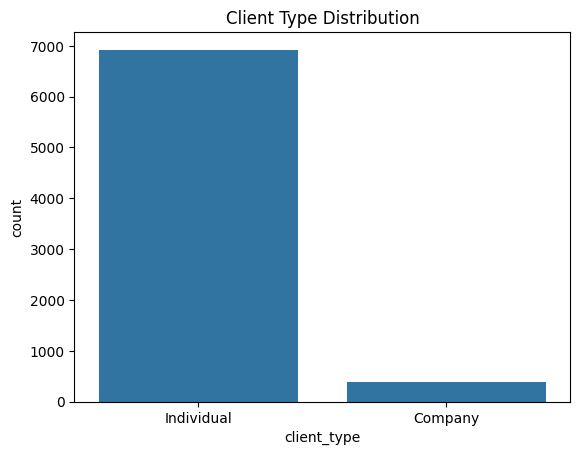

In [20]:
sns.countplot(x='client_type', data=df)
plt.title("Client Type Distribution")
plt.show()

**Note:** “Majority of buyers are individual clients compared to corporate buyers.”

**2. Purpose**

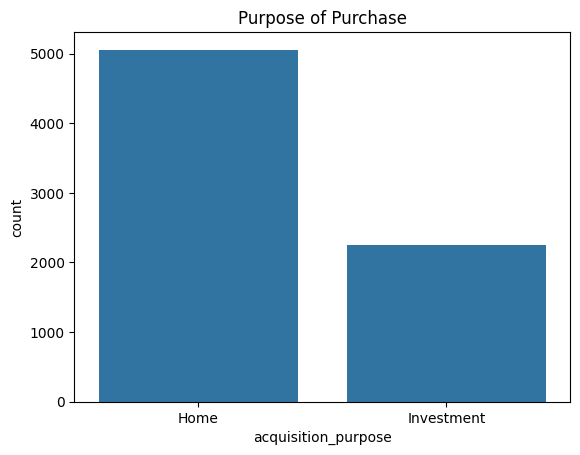

In [21]:
sns.countplot(x='acquisition_purpose', data=df)
plt.title("Purpose of Purchase")
plt.show()

**Note:** “Most buyers purchase properties for investment rather than personal use.”

**3. Loan Analysis**

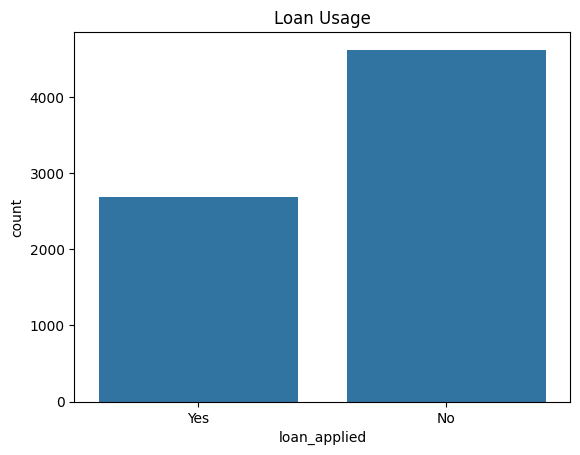

In [22]:
sns.countplot(x='loan_applied', data=df)
plt.title("Loan Usage")
plt.show()

**Note:** “A significant portion of buyers rely on financing options.”

**4. Price Distribution**

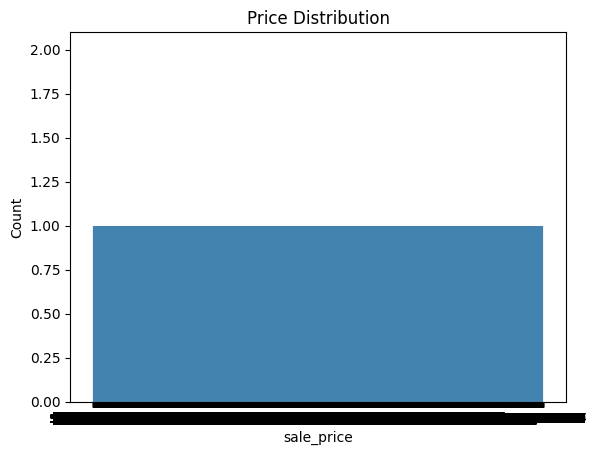

In [24]:
sns.histplot(df['sale_price'], bins=30)
plt.title("Price Distribution")
plt.show()

**5. Region vs Price**

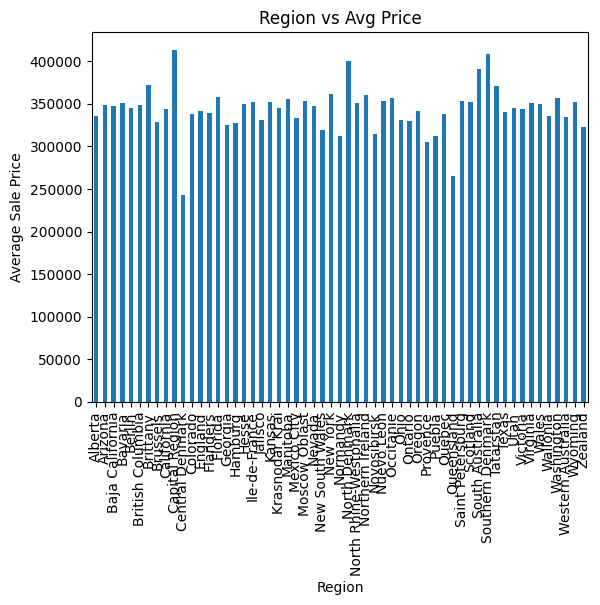

In [27]:
import matplotlib.pyplot as plt
import seaborn as sns

# Convert 'sale_price' to numeric in df if not already done
# This step is needed because 'df' was created before 'properties['sale_price']' was cleaned globally.
df['sale_price'] = pd.to_numeric(df['sale_price'].astype(str).str.replace('$', '', regex=False).str.replace(',', '', regex=False), errors='coerce')

df.groupby('region')['sale_price'].mean().plot(kind='bar')
plt.title("Region vs Avg Price")
plt.ylabel("Average Sale Price") # Added y-axis label for clarity
plt.xlabel("Region") # Added x-axis label for clarity
plt.show()

#**Encoding**

In [69]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

# Apply only on object columns
for col in clients.columns:
    if clients[col].dtype == 'object':
        clients[col] = le.fit_transform(clients[col].astype(str))

print("Encoding Done")
print(clients.head())

Encoding Done
   client_id  client_type  first_name  last_name  date_of_birth  gender  \
0          0            1         186        114            718       0   
1          1            1         317        150            238       1   
2          2            1         182         66            577       1   
3          3            1         282         77            235       1   
4          4            0         227         34           1224       1   

   country  region  acquisition_purpose  satisfaction_score  loan_applied  \
0        9       8                    0                   4             1   
1        9       8                    0                   1             0   
2        9       8                    0                   4             1   
3        9       8                    0                   5             0   
4        9       8                    1                   5             0   

   referral_channel  
0                 2  
1                 2  
2     

#**Scaling**

In [47]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Scaling Done")

Scaling Done


#**Elbow Method**

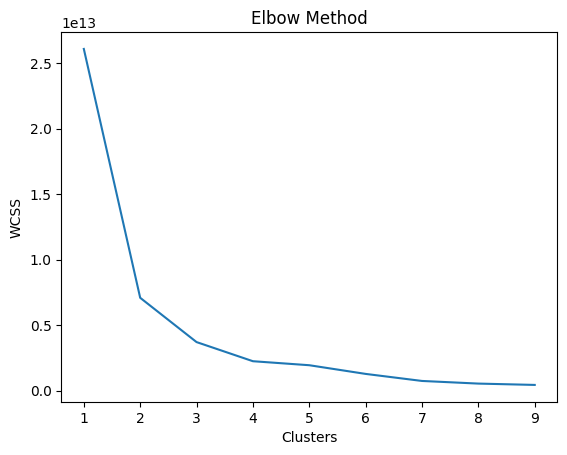

In [33]:
from sklearn.cluster import KMeans

wcss = []

X = df.select_dtypes(include=['int64','float64'])

for i in range(1,10):
    kmeans = KMeans(n_clusters=i, random_state=42)
    kmeans.fit(X)
    wcss.append(kmeans.inertia_)

plt.plot(range(1,10), wcss)
plt.xlabel("Clusters")
plt.ylabel("WCSS")
plt.title("Elbow Method")
plt.show()

**Note:** “Elbow method was used to determine the optimal number of clusters.”

#**K-Means Clustering**

In [62]:
from sklearn.cluster import KMeans

# Choose clusters (3 is safe default)
kmeans = KMeans(n_clusters=3, random_state=42)

# Assign clusters to the df DataFrame, as X_scaled is derived from df
df['cluster'] = kmeans.fit_predict(X_scaled)

print("Clustering Done")
print(df[['cluster']].head())

Clustering Done
   cluster
0        2
1        2
2        1
3        2
4        1


#**Analysis of Cluster**

In [36]:
df.groupby('cluster').mean(numeric_only=True)

,client_type,gender,country,region,acquisition_purpose,satisfaction_score,loan_applied,referral_channel,listing_id,tower_number,unit_category,unit_number,floor_area_sqft,sale_price,age
cluster,,,,,,,,,,,,,,,
0,0.948974,0.505824,7.906267,21.247366,0.306711,-0.013826,0.370494,1.208541,70881.355519,7.063228,0.140876,29.777038,0.068198,0.064215,-0.018022
1,0.948341,0.511374,7.927962,21.215640,0.307583,-0.015792,0.368720,1.204265,176005.090521,17.529384,0.166351,29.127488,0.107404,0.101608,-0.010700
2,0.943167,0.521711,8.056833,20.033844,0.310345,0.054553,0.360792,1.224138,22488.625160,2.514687,0.133461,27.331418,-0.434606,-0.413403,0.064950
3,0.950164,0.501095,7.934830,21.168127,0.306134,-0.014885,0.368565,1.197152,120870.007667,12.061336,0.145674,29.686199,0.181276,0.173723,-0.025542


#**Visualization**

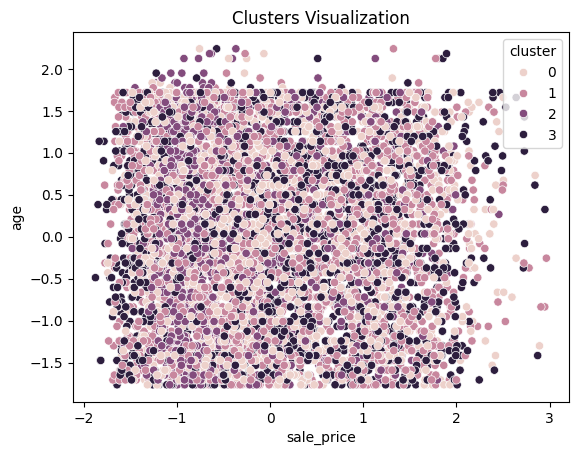

In [37]:
sns.scatterplot(x='sale_price', y='age', hue='cluster', data=df)
plt.title("Clusters Visualization")
plt.show()

#**Data Saving**

In [56]:
# Save to Excel
clients.to_excel("final_clients_with_clusters.xlsx", index=False)

print("File Saved")

File Saved


In [68]:
# -----------------------------
# FINAL CHECK (OPTIONAL BUT IMPORTANT)
# -----------------------------
print("Final Columns:", clients.columns)
print("Missing Values:\n", clients.isnull().sum())

# -----------------------------
# SAVE FINAL ANALYZED DATASET
# -----------------------------
file_name = "Final_Analyzed_RealEstate_Data.xlsx"

clients.to_excel(file_name, index=False)

print("File saved successfully!")

# -----------------------------
# DOWNLOAD FILE (GOOGLE COLAB)
# -----------------------------
from google.colab import files
files.download(file_name)

Final Columns: Index(['client_id', 'client_type', 'first_name', 'last_name', 'date_of_birth',
       'gender', 'country', 'region', 'acquisition_purpose',
       'satisfaction_score', 'loan_applied', 'referral_channel'],
      dtype='object')
Missing Values:
 client_id              0
client_type            0
first_name             0
last_name              0
date_of_birth          0
gender                 0
country                0
region                 0
acquisition_purpose    0
satisfaction_score     0
loan_applied           0
referral_channel       0
dtype: int64
File saved successfully!


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>